
Universidade do Vale do Itajaí <br>
Escola Politécnica <br>
Processamento Digital de Sinais: Imagens <br>

### Alunos: <br>
1.      Diogo Henrique Ribicki
2.      João Victor da Silva
3.      Pedro Henrique de Paula

# Projeto M2 - Processamento Digital de Imagens

Este notebook registra a Sprint 1 do projeto de segmentação automática de células em imagens microscópicas. O objetivo final do trabalho é construir um pipeline clássico de PDI, sem Deep Learning, usando técnicas como filtragem, morfologia matemática, superpixels, pós-processamento e avaliação quantitativa.

## 1. Contexto do problema

A segmentação de células em imagens microscópicas é uma tarefa importante para análise quantitativa em imagens biológicas. Nesta primeira sprint, o foco é preparar a base do projeto: organizar pastas, carregar imagens e máscaras, visualizar amostras e iniciar a análise exploratória por histogramas.

## 2. Dataset escolhido

O dataset escolhido inicialmente contém imagens coloridas de células sanguíneas. As imagens de trabalho desta sprint ficam em `data/samples/images`, e as máscaras de referência correspondentes devem ficar em `data/samples/masks` com o mesmo nome-base das imagens.

## 3. Estrutura do projeto

A estrutura usada nesta sprint separa dados brutos, amostras, código reutilizável, notebooks e saídas geradas:

```text
data/
  raw/
    images/
    masks/
  processed/
  samples/
    images/
    masks/
notebooks/
src/
outputs/
  figures/
  reports/
```

## 4. Carregamento das imagens

In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis import convert_rgb_to_grayscale, show_grayscale_histogram, show_rgb_histogram, summarize_histogram
from src.data_loader import (
    describe_image,
    find_matching_mask,
    inspect_mask,
    list_image_files,
    load_color_image,
    load_grayscale_image,
    validate_image_mask_pair,
)
from src.visualization import show_image_and_mask, show_images_grid, show_mask_overlay

In [2]:
sample_images_dir = project_root / "data" / "samples" / "images"
sample_masks_dir = project_root / "data" / "samples" / "masks"

image_paths = list_image_files(sample_images_dir)[:5]

if len(image_paths) < 5:
    raise RuntimeError("Pelo menos 5 imagens são esperadas dentro do diretório.")

images = [load_color_image(path) for path in image_paths]
image_names = [path.name for path in image_paths]

print(f"Imagens carregadas: {len(images)}")

Imagens carregadas: 5


In [3]:
for image_path, image in zip(image_paths, images):
    info = describe_image(image)
    print(f"Imagem: {image_path.name}")
    print(f"Dimensões: {info['shape']}")
    print(f"Tipo: {info['dtype']}")
    print(f"Min: {info['min']}")
    print(f"Max: {info['max']}")
    print(f"Canais: {info['channels']}")
    print("-" * 40)

Imagem: BloodImage_00000.jpg
Dimensões: (480, 640, 3)
Tipo: uint8
Min: 107
Max: 255
Canais: 3
----------------------------------------
Imagem: BloodImage_00001.jpg
Dimensões: (480, 640, 3)
Tipo: uint8
Min: 98
Max: 255
Canais: 3
----------------------------------------
Imagem: BloodImage_00002.jpg
Dimensões: (480, 640, 3)
Tipo: uint8
Min: 104
Max: 254
Canais: 3
----------------------------------------
Imagem: BloodImage_00003.jpg
Dimensões: (480, 640, 3)
Tipo: uint8
Min: 101
Max: 255
Canais: 3
----------------------------------------
Imagem: BloodImage_00004.jpg
Dimensões: (480, 640, 3)
Tipo: uint8
Min: 94
Max: 255
Canais: 3
----------------------------------------


## 5. Visualização das imagens escolhidas

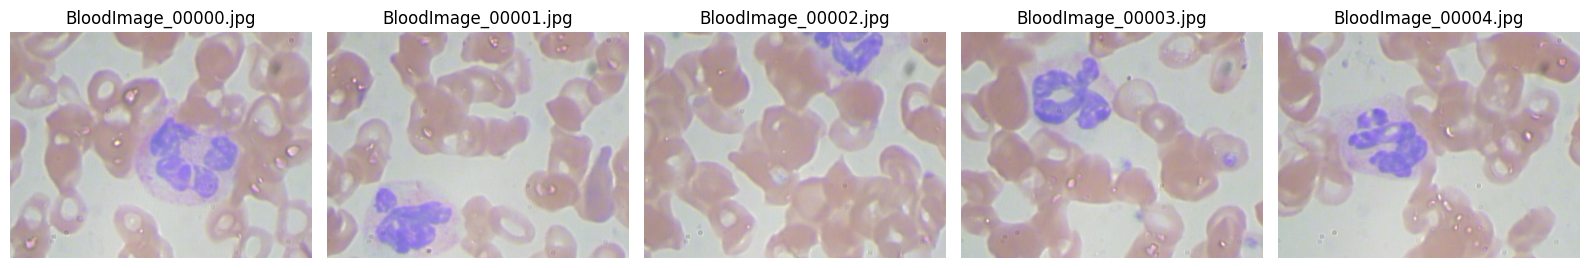

In [4]:
show_images_grid(images, titles=image_names, cols=5, figsize=(16, 4))

## 6. Histogramas e análise inicial

A análise dos histogramas mostra a distribuição dos pixels nos canais RGB e em escala de cinza. Essa etapa ajuda a verificar se há separação visual entre células e fundo, se existe variação forte de iluminação e se uma limiarização global tende a ser suficiente ou se serão necessárias abordagens por cor, superpixels ou pós-processamento morfológico.

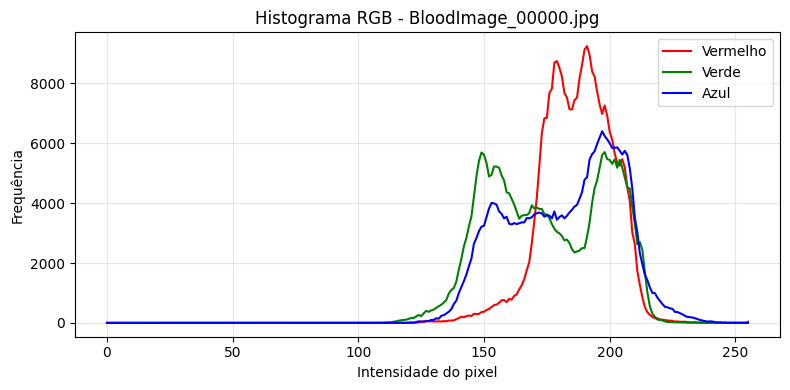

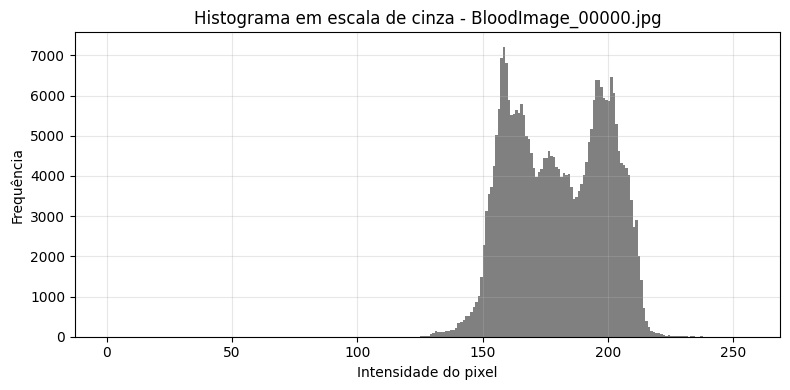

{'mean': 179.77844401041668, 'std': 18.932475823517194, 'min': 121, 'max': 252}

In [5]:
selected_index = 0
selected_image = images[selected_index]
selected_name = image_names[selected_index]
selected_gray = convert_rgb_to_grayscale(selected_image)

show_rgb_histogram(selected_image, title=f"Histograma RGB - {selected_name}")
show_grayscale_histogram(selected_gray, title=f"Histograma em escala de cinza - {selected_name}")

summarize_histogram(selected_gray)

Comentários iniciais:

- As imagens possuem fundo claro e células com variações de tons em azul, roxo e vermelho.
- A variação de cor sugere que apenas uma limiarização global em escala de cinza pode não separar todos os objetos de interesse.
- Regiões com células sobrepostas, bordas suaves e iluminação não uniforme devem exigir pré-processamento e pós-processamento morfológico nas próximas sprints.
- A análise por canais RGB pode ajudar a escolher espaços de cor ou combinações de canais mais adequadas para destacar células do fundo.

## 7. Validação das máscaras de referência

In [6]:
mask_records = []

for image_path, image in zip(image_paths, images):
    mask_path = find_matching_mask(image_path, sample_masks_dir)

    if mask_path is None:
        mask_records.append(
            {
                "image": image_path.name,
                "mask_path": None,
                "exists": False,
                "compatible_shape": False,
                "is_binary": False,
                "unique_values": [],
            }
        )
        print(f"Máscara não encontrada para {image_path.name}")
        continue

    mask = load_grayscale_image(mask_path)
    mask_info = inspect_mask(mask)
    compatible_shape = validate_image_mask_pair(image, mask)

    mask_records.append(
        {
            "image": image_path.name,
            "mask_path": mask_path.name,
            "exists": True,
            "compatible_shape": compatible_shape,
            "is_binary": mask_info["is_binary"],
            "unique_values": mask_info["unique_values"],
            "shape": mask_info["shape"],
            "dtype": mask_info["dtype"],
        }
    )

    print(f"Imagem: {image_path.name}")
    print(f"Máscara: {mask_path.name}")
    print(f"Dimensões da máscara: {mask_info['shape']}")
    print(f"Dimensões compatíveis: {compatible_shape}")
    print(f"Tipo da máscara: {mask_info['dtype']}")
    print(f"Valores únicos: {mask_info['unique_values']}")
    print(f"Máscara binária: {mask_info['is_binary']}")
    print("-" * 40)

mask_records

Máscara não encontrada para BloodImage_00000.jpg
Máscara não encontrada para BloodImage_00001.jpg
Máscara não encontrada para BloodImage_00002.jpg
Máscara não encontrada para BloodImage_00003.jpg
Máscara não encontrada para BloodImage_00004.jpg


[{'image': 'BloodImage_00000.jpg',
  'mask_path': None,
  'exists': False,
  'compatible_shape': False,
  'is_binary': False,
  'unique_values': []},
 {'image': 'BloodImage_00001.jpg',
  'mask_path': None,
  'exists': False,
  'compatible_shape': False,
  'is_binary': False,
  'unique_values': []},
 {'image': 'BloodImage_00002.jpg',
  'mask_path': None,
  'exists': False,
  'compatible_shape': False,
  'is_binary': False,
  'unique_values': []},
 {'image': 'BloodImage_00003.jpg',
  'mask_path': None,
  'exists': False,
  'compatible_shape': False,
  'is_binary': False,
  'unique_values': []},
 {'image': 'BloodImage_00004.jpg',
  'mask_path': None,
  'exists': False,
  'compatible_shape': False,
  'is_binary': False,
  'unique_values': []}]

In [7]:
for image_path, image in zip(image_paths, images):
    mask_path = find_matching_mask(image_path, sample_masks_dir)

    if mask_path is None:
        print(f"Pulando visualização para {image_path.name}: máscara não encontrada.")
        continue

    mask = load_grayscale_image(mask_path)
    show_image_and_mask(image, mask, image_title=image_path.name, mask_title=mask_path.name)
    show_mask_overlay(image, mask, title=f"Sobreposição - {image_path.name}")

Pulando visualização para BloodImage_00000.jpg: máscara não encontrada.
Pulando visualização para BloodImage_00001.jpg: máscara não encontrada.
Pulando visualização para BloodImage_00002.jpg: máscara não encontrada.
Pulando visualização para BloodImage_00003.jpg: máscara não encontrada.
Pulando visualização para BloodImage_00004.jpg: máscara não encontrada.


Caso alguma máscara não esteja binária, o tratamento final não será feito nesta sprint. A necessidade de conversão será apenas registrada para as próximas etapas do projeto.

## 8. Observações da Sprint 1

In [8]:
loaded_count = len(images)
masks_found = sum(record["exists"] for record in mask_records)
all_masks_exist = masks_found == loaded_count
all_shapes_compatible = all(record["compatible_shape"] for record in mask_records) if mask_records else False
all_masks_binary = all(record["is_binary"] for record in mask_records) if mask_records else False
dataset_ready = all_masks_exist and all_shapes_compatible and all_masks_binary

print(f"1. Quantas imagens foram carregadas? {loaded_count}")
print(f"2. Todas possuem máscara de referência? {all_masks_exist} ({masks_found}/{loaded_count})")
print(f"3. As dimensões de imagem e máscara são compatíveis? {all_shapes_compatible}")
print(f"4. As máscaras estão binárias? {all_masks_binary}")
print("5. Desafios visuais: variação de cor, células próximas/sobrepostas e possível iluminação não uniforme.")
print("6. Histogramas: há diferenças entre canais, mas a separação fundo-células pode não ser suficiente em escala de cinza simples.")
print(f"7. O conjunto de dados está pronto para a próxima sprint? {dataset_ready}")

if not all_masks_exist:
    print("Observação: adicionar as máscaras correspondentes em data/samples/masks antes da avaliação quantitativa.")

1. Quantas imagens foram carregadas? 5
2. Todas possuem máscara de referência? False (0/5)
3. As dimensões de imagem e máscara são compatíveis? False
4. As máscaras estão binárias? False
5. Desafios visuais: variação de cor, células próximas/sobrepostas e possível iluminação não uniforme.
6. Histogramas: há diferenças entre canais, mas a separação fundo-células pode não ser suficiente em escala de cinza simples.
7. O conjunto de dados está pronto para a próxima sprint? False
Observação: adicionar as máscaras correspondentes em data/samples/masks antes da avaliação quantitativa.


Conclusão inicial: a base de código e visualização da Sprint 1 está preparada. As imagens de amostra já podem ser carregadas e analisadas; a continuidade para segmentação e avaliação depende da inclusão das máscaras reais correspondentes quando elas ainda não estiverem disponíveis.